<a id="Design-decisions-and-target-reliability"></a>

# Steel-bar design decisions and LQI acceptability

Compare an economic optimum, target-table screening and a marginal LQI acceptance boundary for a steel bar.

**Before you start:** FORM, failure probabilities and discounted costs.

## Problem and approach

The steel-bar decision follows [Schubert and Faber (2009)](https://www.jcss-lc.org/publications/raie/11_example_jcss_ms_2.pdf). A cross-sectional area changes the resistance; FORM gives the annual failure probability; an economic objective and an LQI criterion determine different decision points. A separate [target-table tutorial](ex_target_reliability.ipynb) extends the decision framework to code classes.

In [1]:
import numpy as np
import pandas as pd
import pystra as ra


## Reliability model

The structural model is deliberately simple so that the decision logic remains visible. The limit state is

$$g(f_y, A_s, S) = f_y A_s - 1000 S$$

where `A_s` is the design variable. For each candidate area, PySTRA runs FORM and returns the annual failure probability and reliability index.

In [2]:
def lsf(fy, As, S):
    return fy * As - 1000 * S


def run_reliability(As):
    limit_state = ra.LimitState(lsf)
    model = ra.StochasticModel()
    model.add_variable(ra.Lognormal("fy", 260, 18.2))
    model.add_variable(ra.Constant("As", As))
    model.add_variable(ra.Gumbel("S", 9.5, 1.5))

    options = ra.AnalysisOptions()
    options.set_e1(1e-6)
    options.set_e2(1e-6)

    form = ra.Form(
        analysis_options=options,
        limit_state=limit_state,
        stochastic_model=model,
    )
    form.run()
    return {"pf": float(np.atleast_1d(form.get_failure())[0]), "beta": form.get_beta()}


In [3]:
as_values = np.array([70, 75, 80, 85.1, 90, 93, 95, 100], dtype=float)
study = ra.DesignStudy(variable="As", values=as_values, analysis=run_reliability)

reliability = study.evaluate()
reliability


,As,pf,beta
0,70.0,0.000570,3.253631
1,75.0,0.000203,3.535666
2,80.0,0.000073,3.798064
3,85.1,0.000026,4.048903
4,90.0,0.000009,4.276350
5,93.0,0.000005,4.409851
6,95.0,0.000003,4.496640
7,100.0,0.000001,4.706519


## A single-situation LQI criterion

Now give the decision a jurisdiction and consequence model. Rackwitz's JCSS SWTP table is kept as a 1999 PPPUS$ anchor [Rackwitz (2008)](https://www.jcss-lc.org/publications/raie/06_risk_backgrounddoc_lqi_philosophy.pdf). For present-day studies, `indexed=True` applies an explicit GDP-per-capita PPP index using World Bank WDI data.

The LQI relation behind the SWTP value is

$$\mathrm{SWTP} = \frac{C_{\Delta,d=2\%,a}g}{q}.$$

The screening target used by Fischer, Barnardo, and Faber [Fischer et al. (2012)](https://www.researchgate.net/publication/289533079_Deriving_target_reliabilities_from_the_LQI) is based on

$$K_1 = \frac{C_1(\gamma_S + \omega)}{\mathrm{SWTP} N_F}.$$

For this first pass the criterion is simple: accept a candidate if its annual failure probability is below the target implied by `K1`.

In [4]:
N_F = 12  # expected fatalities given failure
marginal_safety_cost = 5000

lqi = ra.LQI.from_country(
    "CH",
    indexed=True,
    expected_fatalities_given_failure=N_F,
    marginal_safety_cost=marginal_safety_cost,
)

# Anchor (1999) vs indexed (2024) SWTP for CH, straight from the built-in table.
ra.ddo.swtp_table(indexed=True).loc[
    ["CH"],
    [
        "country",
        "anchor_value_per_life",
        "anchor_price_year",
        "value_per_life",
        "price_year",
        "index_factor",
    ],
]


,country,anchor_value_per_life,anchor_price_year,value_per_life,price_year,index_factor
code,,,,,,
CH,Switzerland,1800000.0,1999,4.999502e+06,2024,2.777501


In [5]:
# The LQI target reliability implied by K1 (rounded LQI source-table class).
pd.DataFrame([lqi.target.to_dict()])


,method,pf,beta,k1,cost_class,variability,source
0,lqi-table,0.00001,4.2,0.000083,small,medium,"Fischer, Barnardo, and Faber (2012), LQI Sympo..."


## Optimize the single design decision

The economic objective follows the same steel-bar calculation, with constant annual benefit, construction cost proportional to `A_s`, and discounted failure costs:

$$Z(A) = b\,a - C_y^*(A) - P_f(A)\left(C_y^*(A) + N_F C_O + C_U\right)a$$

where

- $b$ — constant annual benefit rate,
- $a$ — present-value (annuity) factor over the service life (one constant, $a \approx 43.5$ here for $i=2\%$, $L=100$ yr; despite the usual subscript it is *not* time-indexed),
- $C_y^*(A)$ — construction/safety cost (here $5000\,A_s$),
- $C_O$ — owner-borne compensation cost per fatality (here $1.8\times10^{6}$),
- $C_U$ — other failure cost (here $3\times10^{4}$),
- $N_F$ — expected fatalities given failure.

> **The objective's `C_O` is *not* the societal SWTP.** The owner's compensation cost per life ($C_O = 1.8$ M, used *inside* `failure_cost`) answers "what does failure cost the owner?"; the SWTP used by the LQI criterion (introduced above, $\approx 5.0$ M indexed) answers "what is society willing to pay to avoid the risk?". They are different questions and need not be equal — keeping them separate is the whole point of evaluating an economic objective *subject to* a societal criterion.

`ra.DDO` then combines three separate things: the reliability study, the cost-benefit objective, and the LQI criterion.

In [6]:
economic_objective = ra.CostBenefitModel(
    benefit_rate=1.2e4,
    interest_rate=0.02,
    service_life=100,
    construction_cost=lambda As: 5000 * As,
    # failure cost = rebuild (C_y*) + owner compensation (N_F * C_O) + other (C_U).
    # The per-life C_O here (1.8e6) is the owner's cost, deliberately distinct
    # from the societal SWTP that the LQI criterion applies separately.
    failure_cost=lambda As: 5000 * As + N_F * 1.8e6 + 3e4,
)


Running the DDO object evaluates each area and adds objective, annualized cost, target, and feasibility columns. This is the practical grid-based workflow a designer might use.

In [7]:
ddo = ra.DDO(study=study, objective=economic_objective, criterion=lqi)

results = ddo.run()
results["construction_cost"] = 5000 * results["As"]
results["jcss_lqi_risk_cost"] = lqi.risk_cost(
    results["construction_cost"],
    results["pf"],
)

results[
    [
        "As",
        "pf",
        "beta",
        "objective",
        "annualized_safety_cost",
        "target_pf",
        "lqi_acceptable",
        "jcss_lqi_risk_cost",
    ]
]


,As,pf,beta,objective,annualized_safety_cost,target_pf,lqi_acceptable,jcss_lqi_risk_cost
0,70.0,0.000570,3.253631,-372721.781196,3497.986176,0.00001,False,384178.591097
1,75.0,0.000203,3.535666,-47463.728588,3749.229744,0.00001,False,387201.262612
2,80.0,0.000073,3.798064,52414.925067,3999.705431,0.00001,False,404374.488000
3,85.1,0.000026,4.048903,72134.235091,4254.889431,0.00001,False,427043.592996
4,90.0,0.000009,4.276350,63205.363591,4499.956828,0.00001,True,450569.891660
5,93.0,0.000005,4.409851,52360.698591,4649.975710,0.00001,True,465310.294518
6,95.0,0.000003,4.496640,44013.703577,4749.983441,0.00001,True,475207.086162
7,100.0,0.000001,4.706519,21121.311353,4999.993638,0.00001,True,500075.587349


The unconstrained economic optimum is not necessarily acceptable. `ddo.summary()` tabulates both decision points: `economic_optimum()` reports the economic maximum, while `optimize()` applies the LQI criterion and returns the best feasible grid alternative.

In [8]:
# economic_optimum() ignores the criterion; optimize() applies it. summary()
# tabulates both — the table a designer reads off the study.
economic_best = ddo.economic_optimum()
feasible_best = ddo.optimize()

ddo.summary()


,point,As,pf,beta,objective,lqi_acceptable
0,economic optimum,85.1,0.000026,4.048903,72134.235091,False
1,best feasible,90.0,0.000009,4.276350,63205.363591,True


Text(0.5, 1.0, 'Economic objective and LQI target')

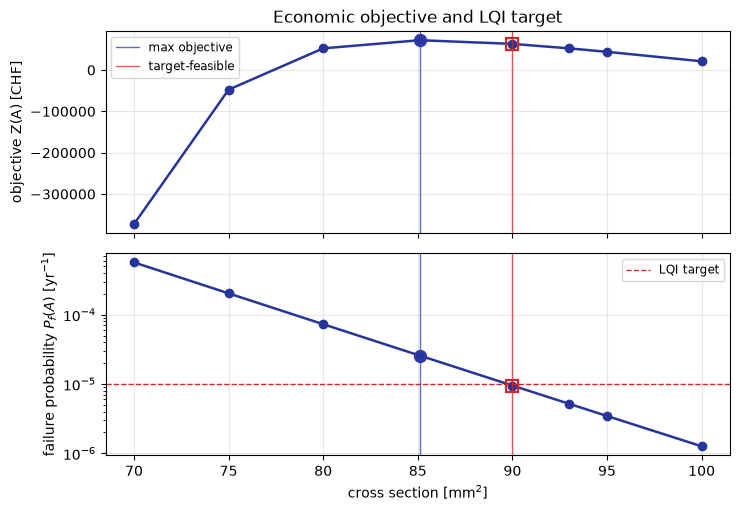

In [9]:
fig, axes = ddo.plot(
    quantities=["objective", "pf"],
    labels={
        "As": r"cross section [mm$^2$]",
        "objective": "objective Z(A) [CHF]",
        "pf": r"failure probability $P_f(A)$ [yr$^{-1}$]",
    },
    reference_designs=[
        {"design": economic_best["As"], "label": "max objective", "marker": "o"},
        {"design": feasible_best["As"], "label": "target-feasible", "marker": "s"},
    ],
    target_failure_probability=lqi.target.pf,
    figsize=(7.5, 5.0),
)
axes[0].set_title("Economic objective and LQI target")


**Figure.** The objective curve and failure-probability curve distinguish the unconstrained economic optimum from a grid design satisfying the LQI target.

## Calibrate the same decision continuously

The grid screening above accepts or rejects discrete candidates. Schubert and Faber instead locate the acceptance *boundary* directly: the design where one more unit of safety stops being socially justified. In the SWTP notation used throughout PySTRA (and in the theory guide), that boundary is the zero of the marginal LQI margin

$$m(A) = \frac{dC_y(A)}{dA} + \mathrm{SWTP}\,N_F\,\frac{dP_f(A)}{dA},$$

which is negative while society would still pay to add safety and non-negative once the marginal cost of safety meets the SWTP-valued risk reduction. `LQI.acceptability_boundary` finds this zero.

This is exactly Schubert and Faber's Equation (2): writing $N_F = N_{PE}\,k$ (people exposed × probability of death given failure) and $\mathrm{SWTP} = C_{\Delta}\,g/q$ (the LQI relation, with income $g$ and the dimensionless work–leisure parameter $q$), the condition $m(A) < 0$ rearranges to $\frac{dP_f}{dA} - \frac{q}{C_{\Delta}N_{PE}kg}\frac{dC_y}{dA} < 0$.

The economic optimum maximizes $Z(A)$; the LQI boundary sits at higher safety because it values the avoided fatalities at the full societal SWTP rather than the owner's compensation cost.

In [10]:
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize_scalar

jcss_designs = np.linspace(70.0, 100.0, 61)
jcss_curve = ra.DesignStudy("As", jcss_designs, run_reliability).evaluate()
jcss_pf = PchipInterpolator(jcss_curve["As"], jcss_curve["pf"])


The next objects use the paper's Table 1 values directly: the LQI relation for Switzerland in 2009, the same objective model as before, and the same expected fatalities `N_F`.

In [11]:
paper_lqi = ra.LQI.from_lqi(
    gross_domestic_product_per_capita=35931.0,
    work_leisure_parameter=0.175,  # q in the LQI relation, not a mortality rate
    demographic_constant=18.9,
    expected_fatalities_given_failure=N_F,
    marginal_safety_cost=5000,
    currency="CHF",
    price_year=2009,
    source="Schubert and Faber (2009), Table 1",
)

# The economic objective is identical to Section 3 — reuse it rather than
# redefining the same cost model.
publication_objective = economic_objective


These functions expose the continuous quantities in Figure 1: failure probability, annualized safety cost, objective value, and the normalized marginal LQI term. The zero of `marginal_lqi_term` is the acceptance boundary.

In [12]:
def pf_at(As):
    return float(jcss_pf(As))


def annualized_cost(As):
    return publication_objective.annualized_safety_cost(As, pf_at(As))


def objective_at(As):
    return publication_objective.objective(As, pf_at(As))


def marginal_lqi_term(As):
    # Raw margin m(A) has units of cost/area; dividing by SWTP * N_F rescales it
    # to Schubert and Faber's dimensionless Equation (2) plotting form. The zero
    # crossing is unchanged, so it coincides with LQI.acceptability_boundary below.
    margin = paper_lqi.acceptability_margin_at(annualized_cost, pf_at, As, step=1e-3)
    return -margin / paper_lqi.swtp.for_lives(
        paper_lqi.expected_fatalities_given_failure
    )


Now compute the two continuous decision points and compare them with the published values. The target-screening grid point is retained to show how the table method differs from the marginal method.

In [13]:
optimal_as = float(
    minimize_scalar(
        lambda As: -objective_at(As), bounds=(70.0, 100.0), method="bounded"
    ).x
)
# The acceptance boundary is the zero of the marginal LQI margin, found with the
# library helper instead of a hand-rolled root solve.
acceptable_as = paper_lqi.acceptability_boundary(
    annualized_cost, pf_at, bounds=(80.0, 100.0), step=1e-3
)
target_grid_as = float(feasible_best["As"])


In [14]:
jcss_curve["annualized_safety_cost"] = [
    annualized_cost(As) / 1e3 for As in jcss_curve["As"]
]
jcss_curve["lqi_marginal_term"] = [
    marginal_lqi_term(As) * 1e5 for As in jcss_curve["As"]
]
jcss_curve["objective"] = [objective_at(As) for As in jcss_curve["As"]]

single_decision_summary = pd.DataFrame(
    [
        {
            "point": "economic optimum",
            "As": optimal_as,
            "published As": 85.1,
            "pf": pf_at(optimal_as),
            "Cy [10^3 CHF/year]": annualized_cost(optimal_as) / 1e3,
            "Z [CHF]": objective_at(optimal_as),
        },
        {
            "point": "LQI marginal boundary",
            "As": acceptable_as,
            "published As": 93.0,
            "pf": pf_at(acceptable_as),
            "Cy [10^3 CHF/year]": annualized_cost(acceptable_as) / 1e3,
            "Z [CHF]": objective_at(acceptable_as),
        },
        {
            "point": "target-screening grid point",
            "As": target_grid_as,
            "published As": np.nan,
            "pf": float(feasible_best["pf"]),
            "Cy [10^3 CHF/year]": feasible_best["annualized_safety_cost"] / 1e3,
            "Z [CHF]": feasible_best["objective"],
        },
    ]
)
single_decision_summary


,point,As,published As,pf,Cy [10^3 CHF/year],Z [CHF]
0,economic optimum,85.128051,85.1,0.000026,4.256293,72134.409874
1,LQI marginal boundary,92.874655,93.0,0.000005,4.643708,52859.806051
2,target-screening grid point,90.000000,NaN,0.000009,4.499957,63205.363591


Text(0.5, 1.01, 'Schubert and Faber JCSS steel-bar example')

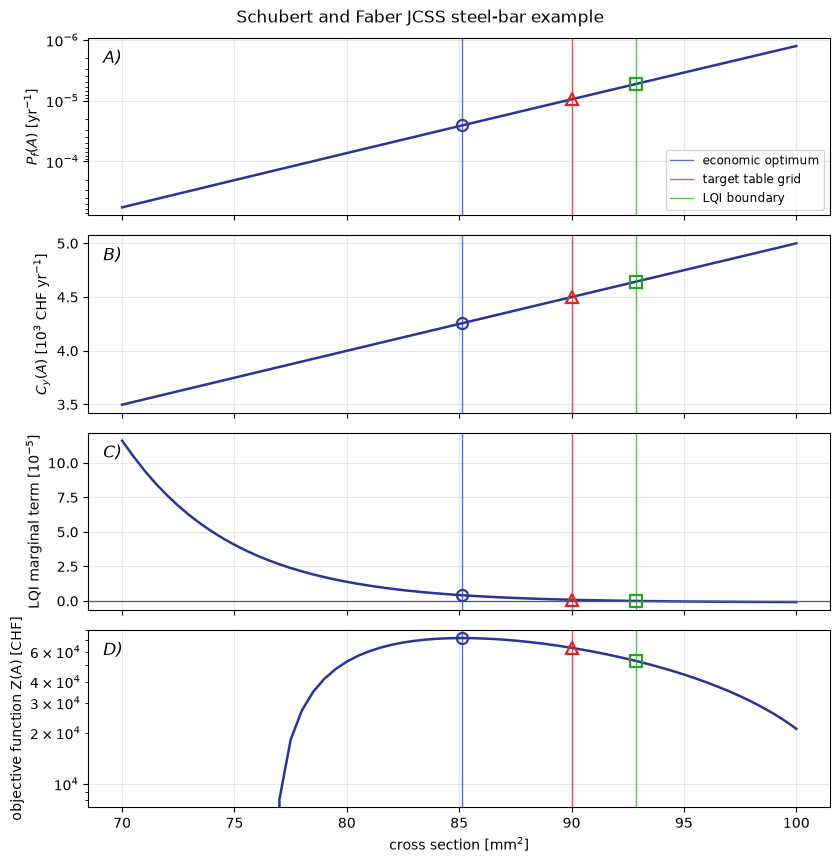

In [15]:
fig, axes = ra.ddo.plot_summary(
    jcss_curve,
    design="As",
    quantities=["pf", "annualized_safety_cost", "lqi_marginal_term", "objective"],
    labels={
        "As": r"cross section [mm$^2$]",
        "pf": r"$P_f(A)$ [yr$^{-1}$]",
        "annualized_safety_cost": r"$C_y(A)$ [$10^3$ CHF yr$^{-1}$]",
        "lqi_marginal_term": r"LQI marginal term [$10^{-5}$]",
        "objective": "objective function Z(A) [CHF]",
    },
    yscales={"pf": "log", "objective": "log"},
    invert_yaxis=["pf"],
    panel_labels=True,
    reference_designs=[
        {"design": optimal_as, "label": "economic optimum", "marker": "o"},
        {"design": target_grid_as, "label": "target table grid", "marker": "^"},
        {"design": acceptable_as, "label": "LQI boundary", "marker": "s"},
    ],
    figsize=(8.5, 8.5),
    line_kwargs={"marker": ""},
)
fig.suptitle("Schubert and Faber JCSS steel-bar example", y=1.01)


**Figure.** Four steel-bar response curves locate the economic optimum, target-table grid point and marginal LQI boundary; these are different decision criteria.

## Interpretation

Economic optimization, target-table screening and a marginal LQI acceptance boundary answer different decision questions. Retain their assumptions and compare the labelled design points before selecting an intervention.

## From one decision to a code-jurisdiction table

Continue with [calibrating target-reliability tables](ex_target_reliability.ipynb#From-a-decision-to-a-target-table) for normalized cost/consequence classes and reference-period conversion.

## Re-target for a new jurisdiction or new settings

The [target-table tutorial](ex_target_reliability.ipynb#Re-target-for-a-new-jurisdiction-or-new-settings) varies model settings and jurisdictional inputs in a standalone notebook.

## Building blocks to reuse

`DesignStudy` evaluates a design grid, `CostBenefitModel` defines the objective, `LQI` supplies a criterion and `DDO` compares the resulting decisions. `LQI.acceptability_boundary` locates the marginal boundary. The [target-table tutorial](ex_target_reliability.ipynb) extends the workflow using `RackwitzTargetModel` and `TargetReliability`.


**Continue:** [User guide](../guides/assessment.rst) · [API reference](../api/decisions.rst) · [Theory](../theory/decisions.rst)